# Task 0: Model Size and Quantization

In this task, I will explain why models like BERT and LLaMA are large and require a lot of memory.

I will also explain quantization and how it can reduce the model size and memory usage.

Finally, I will use some simple Python examples and a graph to compare different numerical precisions.

## 1. Why are BERT and LLaMA large?

Models like BERT and LLaMA contain a large number of parameters.

A parameter is a value that the model learns during training. These parameters are stored in memory and are used when the model makes predictions.

For example, BERT Base has around 110 million parameters, while larger BERT versions can have hundreds of millions of parameters.

Larger language models such as LLaMA can have billions of parameters.

The number of parameters affects:

* Memory usage
* Training time
* Inference time
* Hardware requirements

This means that running a large model can require a powerful GPU and a large amount of RAM or VRAM.

Another factor is how these parameters are stored. Using higher numerical precision requires more memory. This is where quantization can help by using fewer bits to represent the model's parameters.

## 2. The Problem with Large Models

The main problem is that each parameter needs memory to be stored.

For example, if we store each parameter using 32-bit floating point numbers, each parameter needs 32 bits.

We can calculate the approximate memory needed for the model parameters using:

$$
Model\ Memory = Number\ of\ Parameters \times Bytes\ per\ Parameter
$$

Since:

$$
32\ bits = 4\ bytes
$$

A model with 110 million parameters would need approximately:

$$
110,000,000 \times 4 = 440,000,000\ bytes
$$

which is around 440 MB just for the parameters.

This does not include the extra memory needed during training or inference.


## 3. What is Quantization?

Quantization is a technique used to reduce the memory required by a model.

The main idea is to represent model parameters using fewer bits.

For example, instead of storing a parameter using 32 bits, we can use 16 bits, 8 bits, or even 4 bits.

Common precisions are:

* FP32 → 32 bits
* FP16 → 16 bits
* INT8 → 8 bits
* INT4 → 4 bits

Using fewer bits means that the model requires less memory.

However, reducing the number of bits can cause some loss in accuracy because the values are represented with lower precision.

Therefore, there is usually a trade-off between model size and model accuracy.


## 4. Simple Quantization Example

Suppose we have the following values:

$$
[0.12,\ 0.54,\ 0.91,\ 0.33]
$$

In a high precision format, these values can be stored with high precision.

With quantization, these values can be converted to a lower precision representation.

For example, with 8-bit integers, values are represented using integers from:

$$
-128 \text{ to } 127
$$

A scaling factor is used to map the original floating point values to this integer range.

This reduces the amount of memory required to store the values.

The goal is not to keep exactly the same values, but to keep an approximation that is close enough for the model to work correctly.


## 5. Compare the Memory


In [8]:
# Compare the approximate memory needed for different precisions

parameters = 110_000_000

memory_fp32 = parameters * 4
memory_fp16 = parameters * 2
memory_int8 = parameters * 1
memory_int4 = parameters * 0.5

print("FP32:", memory_fp32 / 1_000_000, "MB")
print("FP16:", memory_fp16 / 1_000_000, "MB")
print("INT8:", memory_int8 / 1_000_000, "MB")
print("INT4:", memory_int4 / 1_000_000, "MB")

FP32: 440.0 MB
FP16: 220.0 MB
INT8: 110.0 MB
INT4: 55.0 MB


## 6. Memory Usage Graph


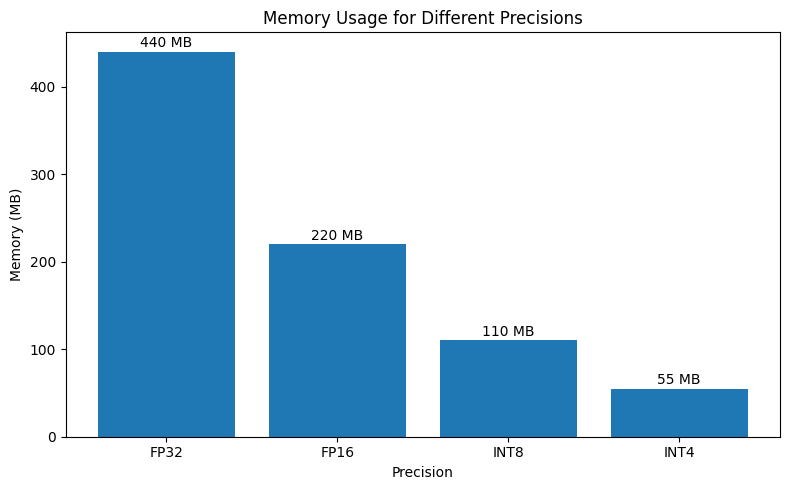

In [9]:
import matplotlib.pyplot as plt

# Memory usage in MB for 110 million parameters
precisions = ["FP32", "FP16", "INT8", "INT4"]
memory = [440, 220, 110, 55]

plt.figure(figsize=(8, 5))
bars = plt.bar(precisions, memory)

plt.title("Memory Usage for Different Precisions")
plt.xlabel("Precision")
plt.ylabel("Memory (MB)")

for bar, value in zip(bars, memory):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f"{value} MB",
        ha="center"
    )

plt.tight_layout()
plt.show()


**Note:** This graph is an approximate example for a model with 110 million parameters. It shows only the memory needed to store the model parameters, not the full runtime memory.

## 7. 8-bit Quantization

The following example shows how to load a pretrained model using 8-bit quantization.

Instead of using the original precision for the model weights, `bitsandbytes` allows the model to load its weights using 8-bit representation.

This can reduce memory usage and make it easier to run larger models on limited hardware.

In [10]:
!pip install -U transformers accelerate bitsandbytes

In [11]:
from transformers import AutoModelForSequenceClassification
from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    quantization_config=quantization_config,
    device_map="auto"
)

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear8bitLt(in_features=768, out_features=768, bias=True)
            (k_lin): Linear8bitLt(in_features=768, out_features=768, bias=True)
            (v_lin): Linear8bitLt(in_features=768, out_features=768, bias=True)
            (out_lin): Linear8bitLt(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropou

## 8. 4-bit Quantization


In [12]:
from transformers import AutoModelForSequenceClassification
from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="float16"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    quantization_config=quantization_config,
    device_map="auto"
)

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear4bit(in_features=768, out_features=768, bias=True)
            (k_lin): Linear4bit(in_features=768, out_features=768, bias=True)
            (v_lin): Linear4bit(in_features=768, out_features=768, bias=True)
            (out_lin): Linear4bit(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1,

## 10. Advantages of Quantization

Quantization has several advantages:

- It reduces the memory usage of the model.
- It makes large models easier to run on limited hardware.
- It can reduce the computational cost during inference.
- It makes model deployment more practical.

## 11. Disadvantages of Quantization

Quantization also has some disadvantages:

- Using fewer bits can reduce model accuracy.
- Very low precision, such as 4-bit, may cause more performance loss.
- Some quantization methods require specific hardware or libraries.
- The model should be tested after quantization to check its performance.

## 12. Conclusion

In this task, I learned why models like BERT and LLaMA can need a lot of memory because they have a large number of parameters.

I also learned how quantization can reduce model size and memory usage by representing parameters with fewer bits. For example, FP16, INT8, and INT4 can significantly reduce the memory required compared to FP32.

Using fewer bits makes large models easier to run on devices with limited resources. However, lower precision can sometimes affect model accuracy and performance. Therefore, the appropriate precision should be chosen based on the available hardware and the required model performance.

Overall, I learned that quantization is a useful technique for making large models smaller and more practical to use.
